In [4]:
import sys
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt 

### Carga de la data limpia

In [5]:
data = pd.read_csv("./../datasets/datosRed_limpio.csv", encoding="ISO-8859-1")
data.head()

,AÑO,PERSONA,TIPO DE SERVICIO,NOMBRE DE LA TAREA,MODALIDAD,COMPLEJIDAD
0,2019,ID_1,SERV_1,TAREA_1.1,PRESENCIAL,BAJA
1,2019,ID_2,SERV_1,TAREA_1.1,PRESENCIAL,BAJA
2,2019,ID_3,SERV_1,TAREA_1.1,PRESENCIAL,BAJA
3,2019,ID_4,SERV_1,TAREA_1.1,PRESENCIAL,BAJA
4,2019,ID_5,SERV_1,TAREA_1.1,PRESENCIAL,BAJA


### Construccion de la red bipartita cliente-servicio

In [6]:
B = nx.Graph()
clientes = data['PERSONA'].unique().tolist()
servicios = data['TIPO DE SERVICIO'].unique().tolist()

# Añadir nodos con el atributo 'bipartite'
B.add_nodes_from(clientes, bipartite="cliente", tipo="CLIENTE")
B.add_nodes_from(servicios, bipartite="servicio", tipo="SERVICIO")

# Añadir aristas entre clientes y servicios
for _, row in data.iterrows():
    cli = row['PERSONA']
    serv = row['TIPO DE SERVICIO']
    if not B.has_edge(cli, serv):
        B.add_edge(cli, serv)

conj_clientes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'cliente']

#Proyeccion ponderada de clientes
G_weighted = bipartite.weighted_projected_graph(B, conj_clientes)

#Proyeccion no ponderada de clientes
G_unweighted = bipartite.projected_graph(B, conj_clientes)

#Utilizamos la ponderada para el analisis
G = G_weighted

In [7]:
#FILTRADO DE LA RED
# Objetivo: Reducir la densidad eliminando enlaces débiles (peso = 1)
print(f"Enlaces originales: {G.number_of_edges()}")

# Creamos una copia para no dañar el original
G_filtrada = nx.Graph()

# Umbral: Solo mantenemos enlaces si comparten MÁS de 1 servicio (weight > 1)
umbral_peso = 1 

for u, v, data in G.edges(data=True):
    if data['weight'] > umbral_peso:
        G_filtrada.add_edge(u, v, weight=data['weight'])

# Actualizamos la red principal 'G' con la versión filtrada
G = G_filtrada

print(f"Enlaces después del filtro (weight > {umbral_peso}): {G.number_of_edges()}")
print(f"Nueva densidad: {nx.density(G):.4f}")

Enlaces originales: 7189307
Enlaces después del filtro (weight > 1): 221489
Nueva densidad: 0.5955


### Visualizacion

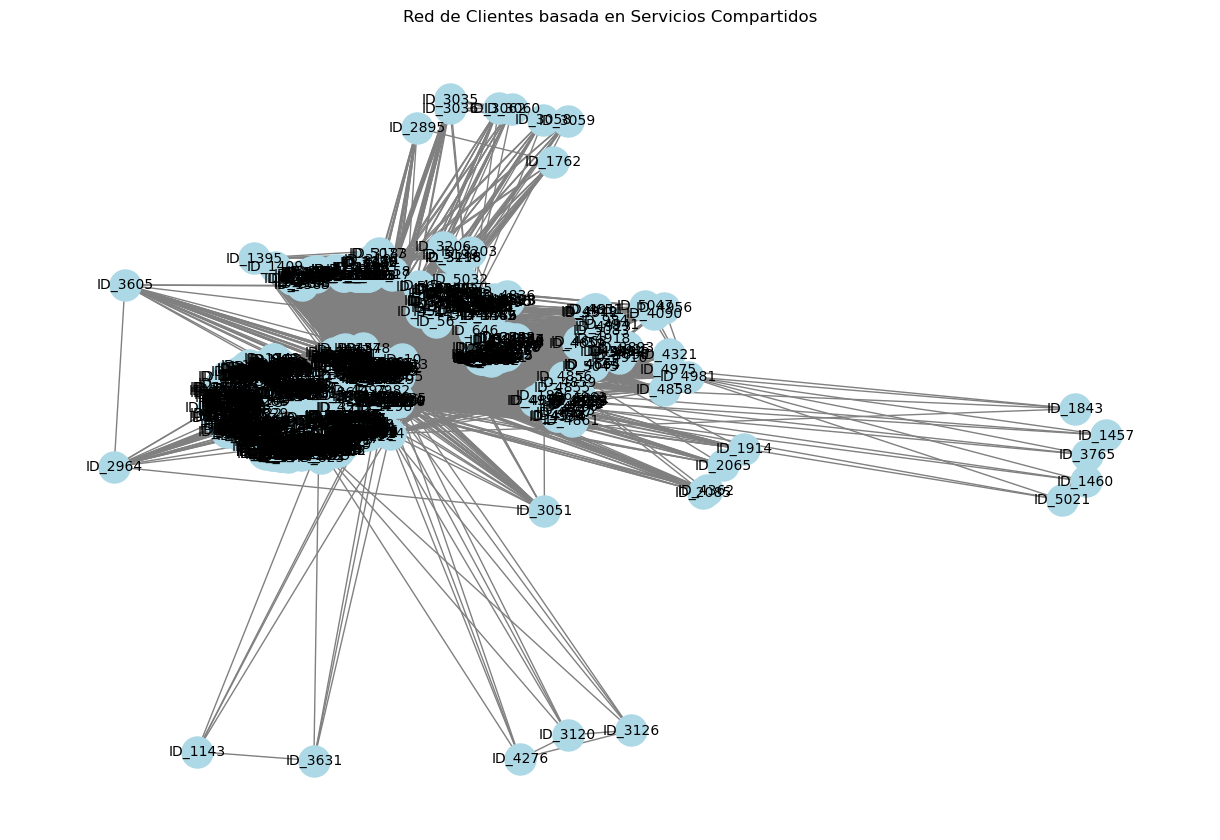

In [8]:
#visualizar el grafo
Graph = plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Posiciones para todos los nod
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=10)
plt.title("Red de Clientes basada en Servicios Compartidos")
plt.show()

### Primeras metricas

In [9]:
#Numeros de nodos
n = G.number_of_nodes()
#Numero de aristas
m = G.number_of_edges()
#Densidad
densidad = nx.density(G)
#Grados
grados = dict(G.degree())
#Grado medio
grado_medio = sum(grados.values()) / n if n > 0 else 0

print("````Primeras métricas de la red de clientes```")
print(f"Nodos (clientes): {n}")
print(f"Enlaces (cliente-cliente): {m}")
print(f"Densidad: {densidad:.4f}")
print(f"Grado medio: {grado_medio:.2f}")

````Primeras métricas de la red de clientes```
Nodos (clientes): 863
Enlaces (cliente-cliente): 221489
Densidad: 0.5955
Grado medio: 513.30


### Comunidades

In [10]:
try:
    import community as community_louvain  # paquete "python-louvain"
    LOUVAIN_AVAILABLE = True
except Exception:
    LOUVAIN_AVAILABLE = False

In [11]:
if LOUVAIN_AVAILABLE and G.number_of_nodes() > 0:
    part = community_louvain.best_partition(G, weight="weight")
    # modularidad
    modularidad = community_louvain.modularity(part, G, weight="weight")
    print(f"Algoritmo: Louvain | Comunidades detectadas: {len(set(part.values()))}")
    print(f"Modularidad: {modularidad:.4f}")
else:
    if G.number_of_nodes() > 0:
        comms = nx.algorithms.community.greedy_modularity_communities(G, weight="weight")
        modularidad = nx.algorithms.community.modularity(G, comms, weight="weight")
        print(f"Algoritmo: Greedy Modularity | Comunidades detectadas: {len(comms)}")
        print(f"Modularidad: {modularidad:.4f}")
        # Convertir a dict tipo {nodo: comunidad_id}
        part = {}
        for cid, cset in enumerate(comms):
            for node in cset:
                part[node] = cid
    else:
        part, modularidad = {}, 0.0
        print("Grafo vacío: no hay comunidades")

Algoritmo: Greedy Modularity | Comunidades detectadas: 2
Modularidad: 0.1879


In [13]:
# --- CARACTERIZACIÓN DE COMUNIDADES ---

# 1. Asegurarnos de que 'data' es el DataFrame correcto (Recarga para evitar el error)
# Ajusta la ruta si es necesario, pero esta es la que usaste arriba
try:
    data = pd.read_csv("./../datasets/datosRed_limpio.csv", encoding="ISO-8859-1")
except FileNotFoundError:
    # Intento alternativo por si la ruta relativa cambia
    data = pd.read_csv("datosRed_limpio.csv", encoding="ISO-8859-1")

# 2. Convertir el diccionario de partición a DataFrame
# 'part' es el diccionario {nodo: comunidad_id} que obtuviste de Louvain
df_comunidades = pd.DataFrame(list(part.items()), columns=['PERSONA', 'Comunidad'])

# 3. Unir con los datos originales
df_analisis = df_comunidades.merge(data, on='PERSONA', how='left')

# 4. Ver resultados
print(f"Total de clientes analizados: {len(df_analisis)}")

# Distribución por Modalidad
print("\n--- Distribución de MODALIDAD por Comunidad (%) ---")
resumen_modalidad = pd.crosstab(df_analisis['Comunidad'], df_analisis['MODALIDAD'], normalize='index')
print((resumen_modalidad * 100).round(2))

# Distribución por Complejidad
print("\n--- Distribución de COMPLEJIDAD por Comunidad (%) ---")
resumen_complejidad = pd.crosstab(df_analisis['Comunidad'], df_analisis['COMPLEJIDAD'], normalize='index')
print((resumen_complejidad * 100).round(2))

# Distribución por Año (Opcional, para ver si hay grupos temporales)
print("\n--- Distribución de AÑO por Comunidad (Promedio) ---")
print(df_analisis.groupby('Comunidad')['AÑO'].mean().round(1))

Total de clientes analizados: 5280

--- Distribución de MODALIDAD por Comunidad (%) ---
MODALIDAD  PRESENCIAL  VIRTUAL
Comunidad                     
0               17.68    82.32
1               83.21    16.79

--- Distribución de COMPLEJIDAD por Comunidad (%) ---
COMPLEJIDAD  ALTA   BAJA  MEDIANA
Comunidad                        
0            0.00  82.04    17.96
1            0.13  43.20    56.67

--- Distribución de AÑO por Comunidad (Promedio) ---
Comunidad
0    2021.7
1    2022.4
Name: AÑO, dtype: float64
